# End-to-End Machine Learning Project: Predicting Medical Insurance Costs

Welcome to this introductory Machine Learning project! In this notebook, we will follow the pedagogical style of **Hands-On Machine Learning (Part 1)** to build a regression model that predicts medical insurance charges based on personal attributes.

## 1. Introduction
We will use the **Medical Cost Personal Datasets**. It contains features like age, sex, BMI, number of children, smoking status, and region to predict the insurance `charges`.
- **Problem:** Supervised Learning (Regression)
- **Why suitable?** It is tabular, contains a mix of categorical and numerical features, and requires clear preprocessing (scaling, encoding) before training models like Linear Regression or Random Forests. It is intuitive and accessible.

In [ ]:
# Quietly install necessary libraries if you are running this notebook for the first time (-q hides the massive output)
%pip install -q pandas numpy matplotlib seaborn scikit-learn

print("✅ Installation check complete. Ready to proceed!")

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# Make this notebook's output stable across runs
np.random.seed(42)

# Plot formatting
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
sns.set_theme(style='whitegrid')

print("✅ Libraries imported successfully!")
print(f"🔹 Python: {sys.version.split(' ')[0]}")
print(f"🔹 Pandas: {pd.__version__}")
print(f"🔹 NumPy: {np.__version__}")
print(f"🔹 Scikit-Learn: {sklearn.__version__}")
print(f"🔹 Seaborn: {sns.__version__}")

✅ Libraries imported successfully!
🔹 Python: 3.14.3
🔹 Pandas: 3.0.1
🔹 NumPy: 2.4.3
🔹 Scikit-Learn: 1.8.0
🔹 Seaborn: 0.13.2


## 2. Data Loading
We can download the dataset directly from a public GitHub repository hosting Kaggle datasets.

In [2]:
url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'
insurance = pd.read_csv(url)

# Apply a modern style to the dataframe to make the output more interactive and attractive
# We show a sample of the first few and last few rows
display(insurance.head(8).style.set_caption("🩺 Medical Insurance Dataset (First 8 Rows)") \
        .set_table_styles([{'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]}]) \
        .background_gradient(subset=['charges', 'bmi'], cmap='Blues'))

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900000,0,yes,southwest,16884.924000
1,18,male,33.770000,1,no,southeast,1725.552300
2,28,male,33.000000,3,no,southeast,4449.462000
3,33,male,22.705000,0,no,northwest,21984.470610
4,32,male,28.880000,0,no,northwest,3866.855200
5,31,female,25.740000,0,no,southeast,3756.621600
6,46,female,33.440000,1,no,southeast,8240.589600
7,37,female,27.740000,3,no,northwest,7281.505600


## 3. Exploratory Data Analysis (EDA)
Let's understand our features and target variable (`charges`).

In [3]:
# Summary statistics for numerical attributes with a visual gradient!
display(insurance.describe().T.style.set_caption("📊 Summary Statistics") \
        .set_table_styles([{'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]}]) \
        .background_gradient(cmap='viridis', axis=1))

,count,mean,std,min,25%,50%,75%,max
age,1338.000000,39.207025,14.049960,18.000000,27.000000,39.000000,51.000000,64.000000
bmi,1338.000000,30.663397,6.098187,15.960000,26.296250,30.400000,34.693750,53.130000
children,1338.000000,1.094918,1.205493,0.000000,0.000000,1.000000,2.000000,5.000000
charges,1338.000000,13270.422265,12110.011237,1121.873900,4740.287150,9382.033000,16639.912515,63770.428010


In [4]:
# A more visual interpretation instead of standard insurance.info()
info_df = pd.DataFrame({
    'Data Type': insurance.dtypes,
    'Non-Null Count': insurance.notnull().sum(),
    'Null Count': insurance.isnull().sum(),
    'Unique Values': insurance.nunique()
})

display(info_df.style.set_caption("📋 Dataset Information & Missing Values") \
        .set_table_styles([{'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]}]) \
        .background_gradient(subset=['Null Count'], cmap='Reds') \
        .background_gradient(subset=['Unique Values'], cmap='Greens'))

,Data Type,Non-Null Count,Null Count,Unique Values
age,int64,1338,0,47
sex,str,1338,0,2
bmi,float64,1338,0,548
children,int64,1338,0,6
smoker,str,1338,0,2
region,str,1338,0,4
charges,float64,1338,0,1337


> *Insight:* There are 1338 instances and 0 missing values. Great! The categorical features are `sex`, `smoker`, and `region`.

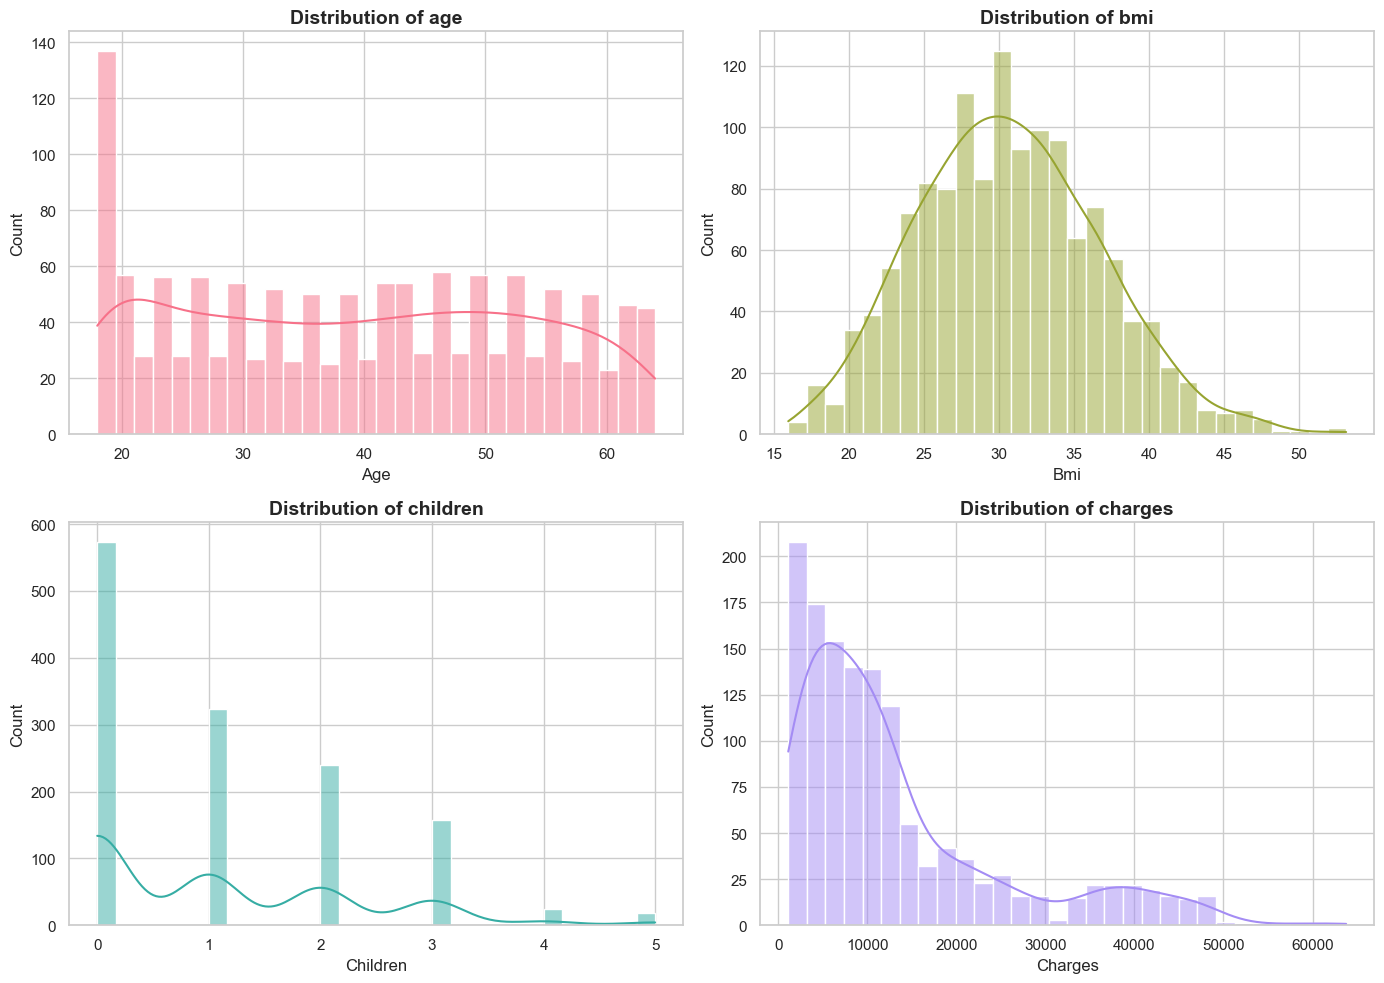

In [6]:
# Visualizing distributions
# We use Seaborn's histplot with a colorful palette and Kernel Density Estimate (KDE) lines for a modern look
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

numeric_cols = insurance.select_dtypes(include=[np.number]).columns
colors = sns.color_palette("husl", len(numeric_cols))

for i, col in enumerate(numeric_cols):
    sns.histplot(insurance[col], kde=True, ax=axes[i], color=colors[i], bins=30)
    axes[i].set_title(f"Distribution of {col}", fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col.capitalize(), fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)
    
plt.tight_layout()
plt.show()

> *Insight:* `charges` is heavily right-skewed. Most people have lower medical costs, but a tail exists for very high costs. `bmi` looks normally distributed.

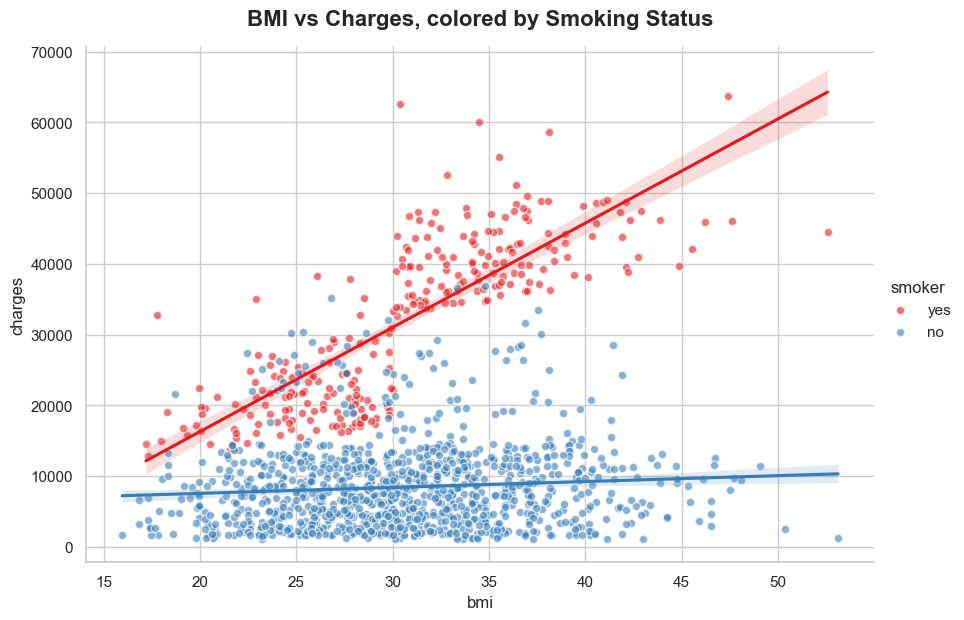

In [5]:
# Creating a scatterplot to see relationships with the target using sns.lmplot for a modern look
sns.lmplot(
    data=insurance, 
    x='bmi', 
    y='charges', 
    hue='smoker', 
    palette='Set1',
    aspect=1.5, 
    height=6,
    scatter_kws={'alpha':0.6, 'edgecolor': 'w'}
)

plt.title('BMI vs Charges, colored by Smoking Status', fontsize=16, fontweight='bold', pad=15)
plt.show()

> *Insight:* Smoking clearly separates the data! Smokers with high BMI have exponentially higher medical charges. This indicates `smoker` is a crucial feature.

Let's also look at the correlation matrix.

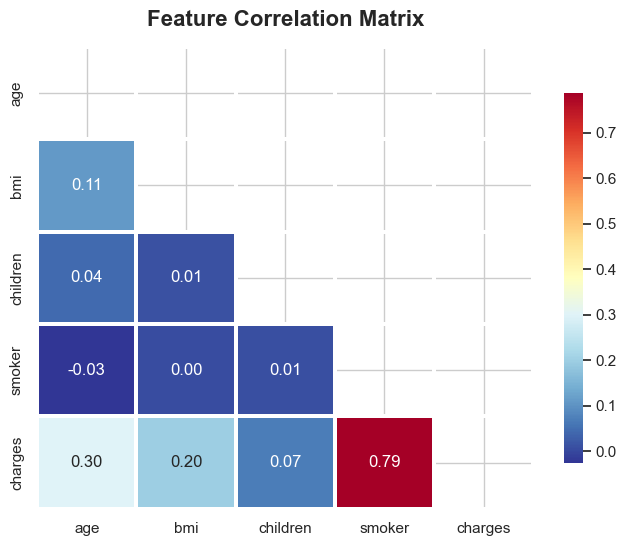

In [6]:
# We'll encode 'smoker' temporarily just to see numerical correlation
corr_df = insurance.copy()
corr_df['smoker'] = corr_df['smoker'].map({'yes': 1, 'no': 0})
corr_mat = corr_df[['age', 'bmi', 'children', 'smoker', 'charges']].corr()

# Create a mask to hide the upper triangle for a cleaner look
mask = np.triu(np.ones_like(corr_mat, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_mat, mask=mask, annot=True, cmap='RdYlBu_r', 
            fmt=".2f", linewidths=1.5, cbar_kws={"shrink": .8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=15)
plt.show()

## 4. Data Preprocessing
Let's split the data, and build a Scikit-Learn Pipeline to handle scaling and encoding.

In [7]:
from sklearn.model_selection import train_test_split

X = insurance.drop('charges', axis=1)
y = insurance['charges']

# 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✂️ Dataset successfully split!")
print(f"Training Set: {X_train.shape[0]} rows")
print(f"Test Set:     {X_test.shape[0]} rows")

✂️ Dataset successfully split!
Training Set: 1070 rows
Test Set:     268 rows


In [8]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn import set_config

num_attribs = ['age', 'bmi', 'children']
cat_attribs = ['sex', 'smoker', 'region']

num_pipeline = Pipeline([
    ('std_scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessing = ColumnTransformer([
    ('num', num_pipeline, num_attribs),
    ('cat', cat_pipeline, cat_attribs),
])

X_train_prepared = preprocessing.fit_transform(X_train)
X_test_prepared = preprocessing.transform(X_test)

# Display interactive Pipeline architecture!
set_config(display='diagram')
preprocessing

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 5. Modeling
We'll try **Linear Regression**, **Decision Tree**, and **Random Forest**.

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

lin_reg = LinearRegression()
lin_reg.fit(X_train_prepared, y_train)

tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train_prepared, y_train)

forest_reg = RandomForestRegressor(random_state=42)
forest_reg.fit(X_train_prepared, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

## 6. Model Evaluation
Let's use Root Mean Squared Error (RMSE) and Cross-Validation to evaluate.

In [11]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score

def get_scores(model, X, y):
    scores = cross_val_score(model, X, y, scoring='neg_mean_squared_error', cv=10)
    rmse_scores = np.sqrt(-scores)
    return {
        "Model": model.__class__.__name__,
        "Mean RMSE": rmse_scores.mean(),
        "Std Dev": rmse_scores.std()
    }

# Gather findings
results = [
    get_scores(lin_reg, X_train_prepared, y_train),
    get_scores(tree_reg, X_train_prepared, y_train),
    get_scores(forest_reg, X_train_prepared, y_train)
]

# Display as a formatted, interactive dataframe
results_df = pd.DataFrame(results).set_index("Model")
display(results_df.style.set_caption("🏆 Cross-Validation Model Comparison") \
        .set_table_styles([{'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]}]) \
        .background_gradient(subset=['Mean RMSE'], cmap='RdYlGn_r') \
        .format("{:.2f}"))

,Mean RMSE,Std Dev
Model,,
LinearRegression,6133.08,520.72
DecisionTreeRegressor,6768.44,534.19
RandomForestRegressor,4957.13,506.42


> *Insight:* Random Forest performs the best overall (lowest Mean RMSE). The Decision Tree is overfitting heavily (worse validation score than Random Forest). Linear Regression is decent but Random Forest captures nonlinear interactions (like the smoking/BMI relationship seen in EDA).

## 7. Hyperparameter Tuning
Let's fine-tune our Random Forest using `GridSearchCV`.

In [12]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {'n_estimators': [30, 50, 100], 'max_features': [2, 4, 6, 8]},
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]}
]

forest_reg_tune = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(forest_reg_tune, param_grid, cv=5, scoring='neg_mean_squared_error', return_train_score=True)
grid_search.fit(X_train_prepared, y_train)

best_model = grid_search.best_estimator_

# Prettify the output
params_df = pd.DataFrame([grid_search.best_params_])
display(params_df.style.set_caption("⚙️ Optimal Random Forest Hyperparameters") \
        .set_table_styles([{'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]}]) \
        .set_properties(**{'background-color': '#f4f4f9', 'color': 'black', 'border-color': 'white'}))

,max_features,n_estimators
0,4,100


## 8. Final Model & Interpretation
We evaluate our final selected and tuned model on the Test Set.

In [13]:
# Use native np.sqrt to avoid deprecation issues in sklearn 1.4+ with mean_squared_error
final_predictions = best_model.predict(X_test_prepared)
final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)
print(f"🎯 Final Test RMSE: {final_rmse:.2f}")

🎯 Final Test RMSE: 4582.24


C:\Users\SMoha\AppData\Local\Temp\ipykernel_30164\3319095956.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[x[0] for x in sorted_importances], y=[x[1] for x in sorted_importances], palette='viridis')


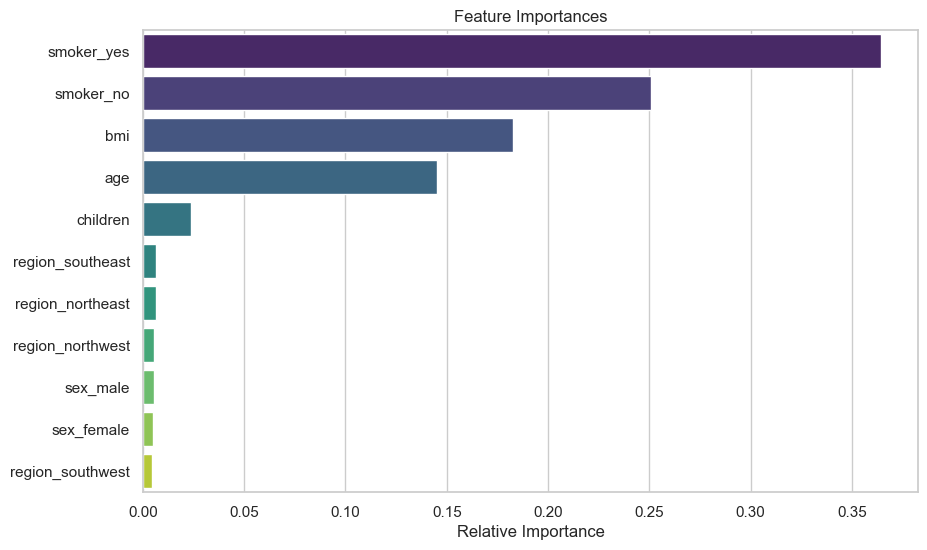

In [14]:
# Feature Importances
feature_importances = best_model.feature_importances_

# Get feature names from the pipeline
cat_encoder = preprocessing.named_transformers_['cat'].named_steps['encoder']
cat_one_hot_attribs = list(cat_encoder.get_feature_names_out(cat_attribs))
attributes = num_attribs + cat_one_hot_attribs

sorted_importances = sorted(zip(feature_importances, attributes), reverse=True)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x=[x[0] for x in sorted_importances], y=[x[1] for x in sorted_importances], palette='viridis')
plt.title('Feature Importances')
plt.xlabel('Relative Importance')
plt.show()

> *Insight:* `smoker_yes` is overwhelmingly the most important feature, followed by `bmi` and `age`. This aligns perfectly with our earlier EDA!

## 9. Conclusion
- **Summary:** We successfully explored the Medical Insurance dataset and built a Random Forest Regressor to predict charges. Over 60% of the model's predictive power comes from knowing whether a patient smokes.
- **Limitations:** The model may struggle with extreme outliers (exceedingly rare medical conditions not represented in generic features). The dataset is relatively small, which limits the diversity of cases.
- **Extensions:** We could explore feature engineering (e.g., categorizing BMI into bins like "Obese" vs "Normal" and creating interactions with 'smoker'.)